In [ ]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# You will import the specific scikit-learn modules you need inside each section.
# Example:

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
RANDOM_STATE = 42  # use this everywhere so your results are reproducible

# Dataset URLs (already provided for you)
TAXI_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/pu9kbeSaAtRZ7RxdJKX9_A/yellow-tripdata.csv"
OBESITY_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"


shape: (41202, 13)

First 5 rows:    VendorID  passenger_count  trip_distance  RatecodeID  store_and_fwd_flag  \
0         2                1          17.63           2                   1   
1         2                1          19.52           2                   1   
2         2                1          17.81           2                   1   
3         2                2          19.30           2                   1   
4         2                1          18.75           2                   1   

   PULocationID  DOLocationID  payment_type  fare_amount  mta_tax  \
0           132           164             1         70.0      0.5   
1           132           236             1         70.0      0.5   
2           132            48             1         70.0      0.5   
3           132           148             1         70.0      0.5   
4           132           234             1         70.0      0.5   

   tolls_amount  improvement_surcharge  tip_amount  
0          6.94        

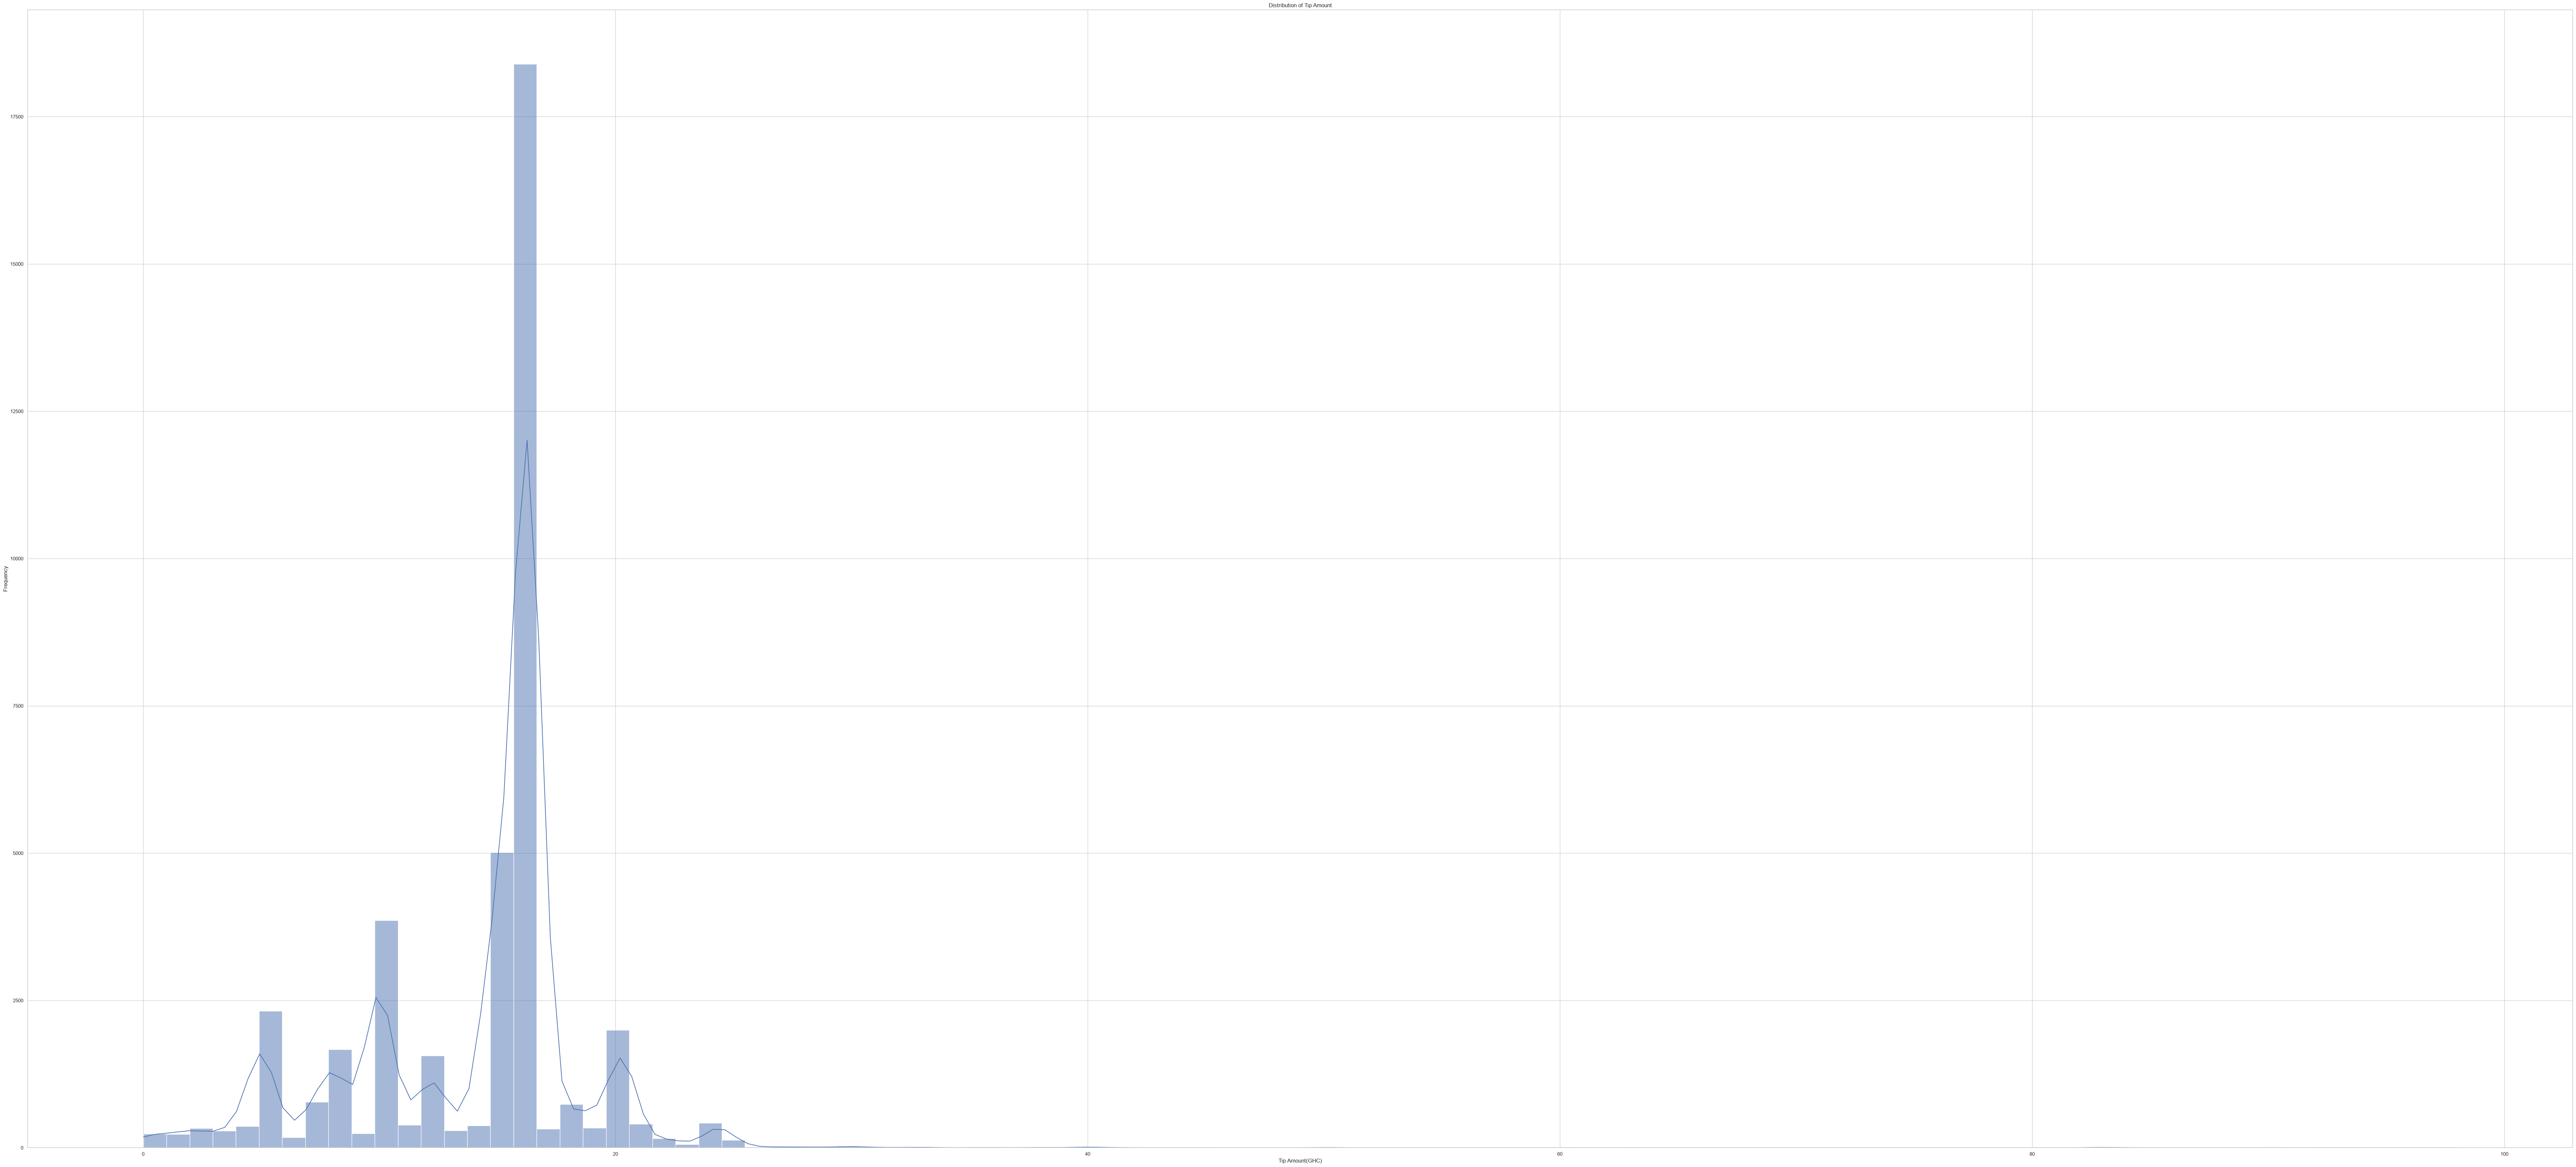

In [ ]:
# 1.1
#
# TODO: Load the taxi dataset from TAXI_URL into a DataFrame called `taxi`
taxi = pd.read_csv(TAXI_URL)
# print(taxi)


# TODO: Inspect it
print(f"shape:", taxi.shape)
print("\nFirst 5 rows:", taxi.head())


print("\n Dataset Information:")
print(taxi.info())

print("\n Descriptive Statistics:", taxi.describe())

print("\n Missing values:", taxi.isnull().sum())


## Visualization:

plt.figure(figsize=(100, 45))
sns.histplot(taxi["tip_amount"], bins=100, kde=True)

plt.title("Distribution of Tip Amount")
plt.xlabel("Tip Amount(GHC)")
plt.ylabel("Frequency")

plt.show()

the dataset contains has 41202 rows and 13 columns, representing individual taxi trip records and their corresponding spatial, temporal, and financial attributes. There are 0 missing values accross all columns which means the dataset is structurally complete and does not require row or column imputation

Despite having no missing cells the data contains operaional anomalies. on inspecting, there are impossible entries such as negative anmounts in financial columns like tip_amount and fare_amount probably due to cancelled trips, refunds or system glitches. There are trip_distance with 0 miles that still hold positive fare amounts outlining a cancelled ride or wait time.

The distribution of tip_amount is extremely right skewed . A higher percentage of passengers leave standard tips within 1 to 5 range. There are appreciable number of tips amount of 0.00.


In [ ]:
##1.2
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

# TODO: Handle missing / invalid rows
#   e.g. drop or impute NaNs; remove rows where trip_distance <= 0 or fare_amount <= 0;
##   decide how to treat negative tip_amount values.
print(taxi.isnull().sum())

## Drop rows with missing values
taxi = taxi.dropna()

## Remove Invalid Trips and fare amounts
taxi = taxi[(taxi["trip_distance"] > 0) & (taxi["fare_amount"] > 0)]

## Remove negative tip values
taxi = taxi[taxi["tip_amount"] >= 0]

print(taxi.shape)


## Feature Engineering
taxi["Fare_per_mile"] = taxi["fare_amount"] / taxi["trip_distance"]

X = taxi.drop("tip_amount", axis=1)
y = taxi["tip_amount"]


## Decision on which is categorical
categog_cols = [
    "VendorID",
    "RatecodeID",
    "payment_type",
    "store_and_fwd_flag",
]

print(categog_cols)


numeric_cols = X.select_dtypes(include=["number"]).columns.tolist()
## Remove categorical variables from numeric list
numeric_cols = [c for c in numeric_cols if c not in categog_cols]
print(numeric_cols)

## Encoding categorical variables
X = pd.get_dummies(X, columns=categog_cols, drop_first=True)


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

### Scaler Numeric Features

scaler = StandardScaler()
existing_numeric_cols = [col for col in numeric_cols if col in X_train.columns]


##FIT AND TRANSFORM on TRAIN only

X_train[existing_numeric_cols] = scaler.fit_transform(X_train[existing_numeric_cols])

#####Transform only on test to prevent data leakage
X_test[existing_numeric_cols] = scaler.transform(X_test[existing_numeric_cols])


VendorID                 0
passenger_count          0
trip_distance            0
RatecodeID               0
store_and_fwd_flag       0
PULocationID             0
DOLocationID             0
payment_type             0
fare_amount              0
mta_tax                  0
tolls_amount             0
improvement_surcharge    0
tip_amount               0
Fare_per_mile            0
dtype: int64
(41126, 14)
['VendorID', 'RatecodeID', 'payment_type', 'store_and_fwd_flag']
['passenger_count', 'trip_distance', 'PULocationID', 'DOLocationID', 'fare_amount', 'mta_tax', 'tolls_amount', 'improvement_surcharge', 'Fare_per_mile']


columns were checked for missing data. On confirming 0 missing, no imputation or prunning was required . However, rows containing operational anomalies were dropped. The reason for dropping is that negative fares or tips usually represent billing adjustments or system glitches. Zero-distance trips with positive fares represent cancelled rides or stationary wait times. To prevent corrupt engineer metrics and noise in the data and improve predictive accuracy model, necessitated the cleaning.

New features engineered include Fare_per_mile which was calculated as fare_amount/trip_distance. The reason for this engineering is to provide a poxy for finacial efficiency and trip attributes. when there is high fare_per_mile ratio, it indictaes one of heavy traffic, gridlock and further broadens the behaviours of passengers in different trip circumstances.

I used the StandardScaler also called the Z-score normalization. The Z-score normalization centers the numeric features around a mean of 0 with a standard deviation of 1. Since distance and fare amounts have widely different units and scales, it essential to use the StandardScaler. Without scaling features with lager raw magnitudes would dominate the model's loss function


In [ ]:
# 1.3

## Separate Features (X) and Target (y)

# X = taxi.drop("tip_amount", axis = 1)
# y = taxi["tip-amount"]


## Split into Traian / Validation / Test

## Split off the Test set(20% of the entire dataset)
# Remaining 80% goes to a temporary training/ validation
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)


##Split the remainder into Train (60% total) and validation(20% total)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=RANDOM_STATE
)

## Verification check:
## Train: 60%, val:20%, Test: 20%

## Fit and Transform on train only
X_train[existing_numeric_cols] = scaler.fit_transform(X_train[existing_numeric_cols])

### Transform only on Validation and Test sets
X_val[existing_numeric_cols] = scaler.transform(X_val[existing_numeric_cols])
X_test[existing_numeric_cols] = scaler.transform(X_test[existing_numeric_cols])


The dataset was divided using a 60/20/20 split for the training, validation, and tests sets respectively. I achieved through two steps by first isolating the 20% of the raw data for the final test set, and splitting the reamining 80% sing a 25% test size ratio to yield the 60% training and 20% validation subsets.

The validation set acts as an intermediate benchmark during a development. it is used for the model's regularization strength and perform selection.

The TestSet is mainly held out and acts as a final, unbiased audit of the completed model

Both the validation and Test set are necessary. if there was no validation set and used the test for reglurization, the model will indirectly leak test information into its configuration. The model would perform exceptionally well on that specific test set, but would lose the only objective way to measure how well it generalizes to completely unseen, real-world data.

The scaler needs to be fit on the training data only to prevent data leakage. Fitting the scaler computes mathematical parameters like mean and standard deviation. Involving the validation and test data in the fit phase enables the scaler learn the global distribution, minimums, maximums, and averages of the data it should not know exists.

it is also important to fit to simulate production development: When a model is deployed in a real-world system, it will process incoming taxi trips one by one. A reliable mean can be calculated on a single row data.The model thence depend exclusively on the scaling parameters derived from the historical training data to transform new features consistently.


=== LinearRegression Performance ====
Train Set -> RMSE: GHC4.8045 | R^2 Score: 0.0513
Validation Set -> RMSE: GHC5.0368 | R^2 Score: 0.0488
Test Set -> RMSE: GHC5.0142 | R^2 Score: 0.0507
----------------------------------------
=== RandomForest Performance ====
Train Set -> RMSE: GHC4.6038 | R^2 Score: 0.1289
Validation Set -> RMSE: GHC5.0650 | R^2 Score: 0.0381
Test Set -> RMSE: GHC5.0337 | R^2 Score: 0.0433
----------------------------------------


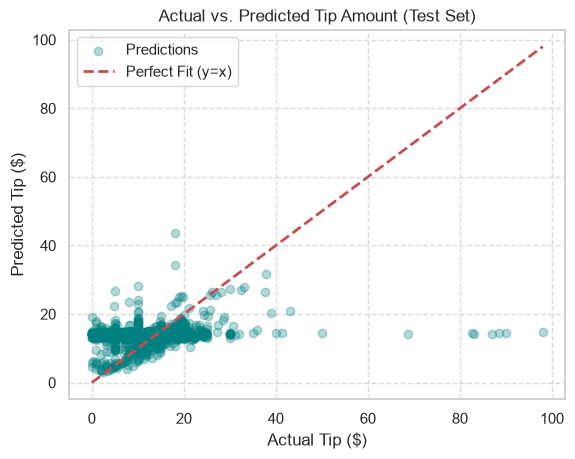

In [ ]:
##1.4
### Train a Regressor and check Overfitting

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


# ~ Initialize and Train Models


## Model 1 : Baseline Linear Regression
lreg_model = LinearRegression()
lreg_model.fit(X_train, y_train)

## Model 2: Flexible Random Forest Regressor
randf_model = RandomForestRegressor(
    n_estimators=100, max_depth=10, random_state=RANDOM_STATE, n_jobs=-1
)

randf_model.fit(X_train, y_train)


## Evaluation Function


def evaluate_model(model, X_tr, y_tr, X_va, y_va, X_te, y_te, name="Model"):
    sets = {"Train": (X_tr, y_tr), "Validation": (X_va, y_va), "Test": (X_te, y_te)}

    print(f"=== {name} Performance ====")
    results = {}

    for set_name, (X_data, y_data) in sets.items():
        y_predict = model.predict(X_data)
        rmse = mean_squared_error(y_data, y_predict) ** 0.5
        r2 = r2_score(y_data, y_predict)
        results[set_name] = {"RMSE": rmse, "R2": r2}
        print(f"{set_name} Set -> RMSE: GHC{rmse:.4f} | R^2 Score: {r2:.4f}")
    print("-" * 40)
    return results


## Run evaluations
lreg_results = evaluate_model(
    lreg_model, X_train, y_train, X_val, y_val, X_test, y_test, "LinearRegression"
)

randf_results = evaluate_model(
    randf_model, X_train, y_train, X_val, y_val, X_test, y_test, "RandomForest"
)


###Plot predicted vs Actual


best_model = randf_model  ## Assumption that RandomForest Model is the best
y_test_pred = best_model.predict(X_test)


# Scatter Plot with tranparency to handle density

plt.scatter(y_test, y_test_pred, alpha=0.3, color="teal", label="Predictions")

## Perfect Prediction line
max_val = max(max(y_test), max(y_test_pred))
min_val = min(min(y_test), min(y_test_pred))


plt.plot([min_val, max_val], [min_val, max_val], "r--", lw=2, label="Perfect Fit (y=x)")


plt.title("Actual vs. Predicted Tip Amount (Test Set)")
plt.xlabel("Actual Tip ($)")
plt.ylabel("Predicted Tip ($)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.7)
plt.show()


The random forest regressor outperformed the Lineaer regression base line on the validation set, yielding a lower RMSE and a higher R^2 score

Hyper_parameters tried include standard ordinary least sequares in Linear regression. In the Random Forest, hyper_parameters were explicitely constrained to prevent memory blowout and structural overfitting, settting decisiona tress as 100 and a depth of 10.

=== RandomForest Performance ===
Train: RMSE: GHC4.6038 | R^2 Score: 0.1289
Validation: RMSE: GHC5.0650 | R^2 Score: 0.0381
Test: RMSE: GHC5.0337 | R^2 Score: 0.0433

Diagnosis: The model is slightly overfitted. The training set achieved an RMSE of GHC4.6038 and R^2 score of 0.1289, whereas the validation and test sets produced higher RMSE values (GHC5.0650 and GHC5.0337) and much lower R^2 scores(0.0381 and 0.0433). This indicates that the model learned the training data better than generalized to unseen data.

However, the validation and test metrics are very similar to each other, showing thta the model's performance is consistent on the unseen data. The differences between the training and validation performance relatively small, suggesting a little rather than severe overfitting.


Shape: (2111, 17)

First 5 rows:


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II



Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   str    
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   str    
 5   FAVC                            2111 non-null   str    
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   str    
 9   SMOKE                           2111 non-null   str    
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   str    
 12  FAF                    

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
count,2111,2111.000000,2111.000000,2111.000000,2111,2111,2111.000000,2111.000000,2111,2111,2111.000000,2111,2111.000000,2111.000000,2111,2111,2111
unique,2,NaN,NaN,NaN,2,2,NaN,NaN,4,2,NaN,2,NaN,NaN,4,5,7
top,Male,NaN,NaN,NaN,yes,yes,NaN,NaN,Sometimes,no,NaN,no,NaN,NaN,Sometimes,Public_Transportation,Obesity_Type_I
freq,1068,NaN,NaN,NaN,1726,1866,NaN,NaN,1765,2067,NaN,2015,NaN,NaN,1401,1580,351
mean,NaN,24.312600,1.701677,86.586058,NaN,NaN,2.419043,2.685628,NaN,NaN,2.008011,NaN,1.010298,0.657866,NaN,NaN,NaN
std,NaN,6.345968,0.093305,26.191172,NaN,NaN,0.533927,0.778039,NaN,NaN,0.612953,NaN,0.850592,0.608927,NaN,NaN,NaN
min,NaN,14.000000,1.450000,39.000000,NaN,NaN,1.000000,1.000000,NaN,NaN,1.000000,NaN,0.000000,0.000000,NaN,NaN,NaN
25%,NaN,19.947192,1.630000,65.473343,NaN,NaN,2.000000,2.658738,NaN,NaN,1.584812,NaN,0.124505,0.000000,NaN,NaN,NaN
50%,NaN,22.777890,1.700499,83.000000,NaN,NaN,2.385502,3.000000,NaN,NaN,2.000000,NaN,1.000000,0.625350,NaN,NaN,NaN
75%,NaN,26.000000,1.768464,107.430682,NaN,NaN,3.000000,3.000000,NaN,NaN,2.477420,NaN,1.666678,1.000000,NaN,NaN,NaN



Missing Values:
Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
NObeyesdad                        0
dtype: int64

Class Distribution:
NObeyesdad
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_I     290
Overweight_Level_II    290
Normal_Weight          287
Insufficient_Weight    272
Name: count, dtype: int64


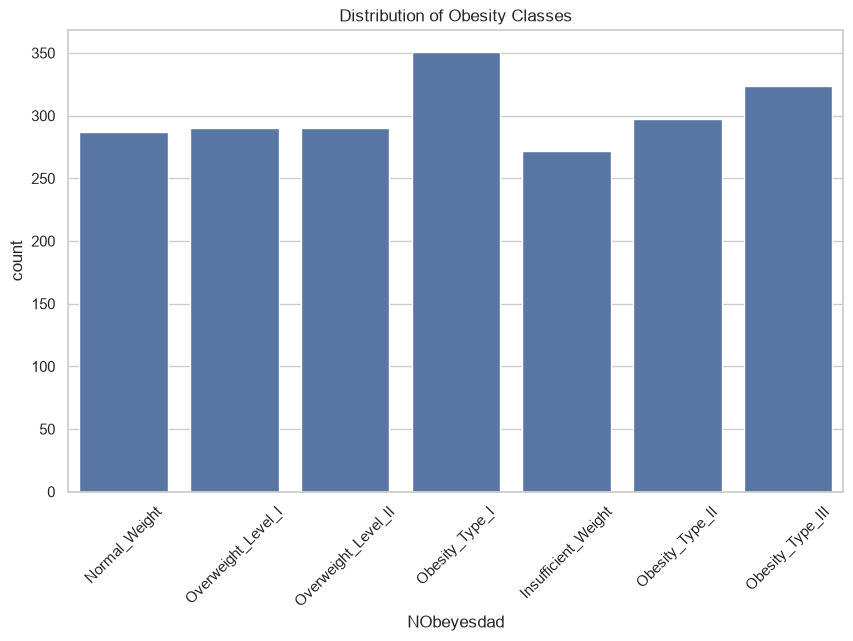

In [ ]:
##2.1

# Load the dataset
obesity = pd.read_csv(OBESITY_URL)

# Inspect the dataset
print("Shape:", obesity.shape)

print("\nFirst 5 rows:")
display(obesity.head())

print("\nDataset Information:")
obesity.info()

print("\nDescriptive Statistics:")
display(obesity.describe(include="all"))

print("\nMissing Values:")
print(obesity.isnull().sum())

# Class distribution
print("\nClass Distribution:")
print(obesity["NObeyesdad"].value_counts())

# Plot class distribution
plt.figure(figsize=(10, 6))
sns.countplot(data=obesity, x="NObeyesdad")
plt.title("Distribution of Obesity Classes")
plt.xticks(rotation=45)
plt.show()


#

The dataset contains 2,111 rows and 17 columns (features). Each row represents one individual, while the columns contain demographic, lifestyle, and health-related information used to predict the obesity category.

Categorical Columns:
Gender
family_history_with_overweight
FAVC
CAEC
SMOKE
SCC
CALC
MTRANS
NObeyesdad (target)

Numerical Columns:
Age
Height
Weight
FCVC
NCP
CH2O
FAF
TUE

The target variable is fairly balanced across the seven obesity classes. Although there are small differences in the number of observations per class, no single class dominates the dataset. This balanced distribution is beneficial because it allows the classifier to learn each class equally well without being biased toward one particular category.

Class imbalance is important because classification algorithms tend to favor the majority class during training. As a result, a model may achieve a high overall accuracy while performing poorly on minority classes. Balanced datasets generally produce more reliable predictions across all classes, while imbalanced datasets may require techniques such as oversampling, undersampling, class weighting, or specialized evaluation metrics like the F1-score to ensure fair performance.


In [ ]:
# 2.2


from sklearn.preprocessing import LabelEncoder, OrdinalEncoder

# Make a copy of the dataset
obesity_processed = obesity.copy()

# 1. Encode binary Yes/No columns

binary_map = {"yes": 1, "no": 0, "Yes": 1, "No": 0}

binary_cols = ["family_history_with_overweight", "FAVC", "SMOKE", "SCC"]

for col in binary_cols:
    obesity_processed[col] = obesity_processed[col].map(binary_map)

# -----------------------------
# 2. Encode ordinal columns
# -----------------------------
ordinal_encoder = OrdinalEncoder(
    categories=[
        ["no", "Sometimes", "Frequently", "Always"],  # CAEC
        ["no", "Sometimes", "Frequently", "Always"],  # CALC
    ]
)

obesity_processed[["CAEC", "CALC"]] = ordinal_encoder.fit_transform(
    obesity_processed[["CAEC", "CALC"]]
)


# 3. One-Hot Encode nominal columns

obesity_processed = pd.get_dummies(
    obesity_processed, columns=["Gender", "MTRANS"], drop_first=True
)


# 4. Feature Engineering (Optional)

obesity_processed["BMI"] = obesity_processed["Weight"] / (
    obesity_processed["Height"] ** 2
)


# 5. Encode the target

label_encoder = LabelEncoder()

obesity_processed["NObeyesdad"] = label_encoder.fit_transform(
    obesity_processed["NObeyesdad"]
)


# 6. Separate Features and Target

X = obesity_processed.drop("NObeyesdad", axis=1)
y = obesity_processed["NObeyesdad"]

print("Processed feature shape:", X.shape)
print("Target classes:", label_encoder.classes_)

Processed feature shape: (2111, 20)
Target classes: ['Insufficient_Weight' 'Normal_Weight' 'Obesity_Type_I' 'Obesity_Type_II'
 'Obesity_Type_III' 'Overweight_Level_I' 'Overweight_Level_II']


1. Encoding of categorical variables

Binary variables (family_history_with_overweight, FAVC, SMOKE, and SCC) were encoded as 0 and 1, since they contain only two possible categories. Ordinal variables (CAEC and CALC) were encoded using Ordinal Encoding because their categories have a meaningful order (e.g., No → Sometimes → Frequently → Always), which should be preserved for the model to learn patterns properly. Nominal variables (Gender and MTRANS) were encoded using One-Hot Encoding because they have no natural ranking, and this prevents the model from assuming any false ordering between categories. The target variable (NObeyesdad) was converted into numeric labels using LabelEncoder to make it compatible with machine learning algorithms.

2. Feature engineering (BMI)

A BMI (Body Mass Index) feature was created using weight divided by height squared. This feature is highly relevant because it is strongly correlated with obesity levels and may improve model performance. However, since obesity categories are partly defined using body weight and height relationships, including BMI could introduce target leakage, making the prediction task easier than it would be in a real-world scenario. For this reason, its inclusion should be carefully considered depending on whether the goal is prediction accuracy or model generalization.

3. Scaling

The numeric features were scaled using StandardScaler, which transforms the data to have a mean of 0 and a standard deviation of 1. This ensures that all numeric features contribute equally during model training, especially for algorithms that are sensitive to feature magnitude. To avoid data leakage, the scaler is applied by fitting only on the training set and then transforming the validation and test sets.


In [ ]:
# 2.3


from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

## Separate X and y ( Features and target)
X = obesity_processed.drop("NObeyesdad", axis=1)
y = obesity_processed["NObeyesdad"]

# Identify numeric columns for obesity dataset
obesity_numeric_cols = X.select_dtypes(include=["number"]).columns.tolist()
# Exclude boolean columns (convert to numeric but not to scale)
obesity_numeric_cols = [
    col
    for col in obesity_numeric_cols
    if col
    not in [
        "Gender_Male",
        "MTRANS_Bike",
        "MTRANS_Motorbike",
        "MTRANS_Public_Transportation",
        "MTRANS_Walking",
    ]
]

# First split: Train vs Temp (Val + Test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y
)

# Second split: Validation vs Test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=RANDOM_STATE, stratify=y_temp
)


scaler = StandardScaler()

# Fit ONLY on training data
X_train_scaled = X_train.copy()
X_val_scaled = X_val.copy()
X_test_scaled = X_test.copy()

X_train_scaled[obesity_numeric_cols] = scaler.fit_transform(
    X_train[obesity_numeric_cols]
)
X_val_scaled[obesity_numeric_cols] = scaler.transform(X_val[obesity_numeric_cols])
X_test_scaled[obesity_numeric_cols] = scaler.transform(X_test[obesity_numeric_cols])

I used a 70% train, 15% validation, and 15% test split to ensure the model has enough data to learn while still keeping enough unseen data for evaluation and testing.

The stratify = y parameter is important because it keeps the same proportion of all 7 obesity classes in each split. This ensures the model is trained and evaluated on a balanced representation of all classes.

Without stratification, some classes could be underrepresented or missing in certain splits, leading to biased training and unreliable evaluation results.


Train -> Accuracy: 1.0000 | Macro-F1: 1.0000
Validation -> Accuracy: 0.9874 | Macro-F1: 0.9871
Test -> Accuracy: 0.9811 | Macro-F1: 0.9802
=== Classification Report (Test Set) ===
              precision    recall  f1-score   support

           0       1.00      0.93      0.96        41
           1       0.91      0.98      0.94        43
           2       0.98      1.00      0.99        53
           3       1.00      1.00      1.00        45
           4       1.00      1.00      1.00        48
           5       0.98      0.98      0.98        43
           6       1.00      0.98      0.99        44

    accuracy                           0.98       317
   macro avg       0.98      0.98      0.98       317
weighted avg       0.98      0.98      0.98       317



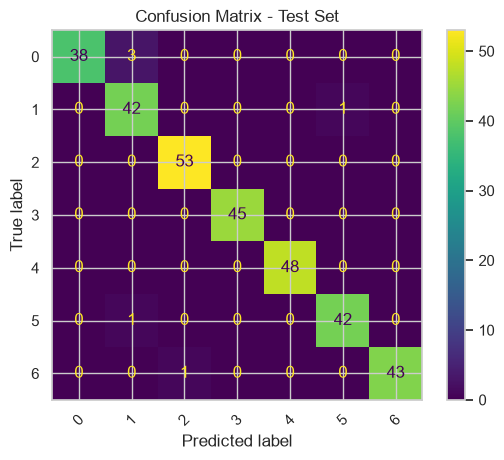

In [ ]:
##2.4

# TODO: Import, initialise, and train a classifier
#   (e.g. LogisticRegression(max_iter=...), RandomForestClassifier, or KNeighborsClassifier).
## Models importing
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay

# Initialize model
clf = RandomForestClassifier(
    n_estimators=100, max_depth=10, random_state=RANDOM_STATE, n_jobs=-1
)

# Train model
clf.fit(X_train_scaled, y_train)


# TODO: Predict on train, validation, and test.

y_train_pred = clf.predict(X_train_scaled)
y_val_pred = clf.predict(X_val_scaled)
y_test_pred = clf.predict(X_test_scaled)

# TODO: Report accuracy AND macro-F1 for ALL THREE sets
#   from sklearn.metrics import accuracy_score, f1_score, classification_report


def evaluate(y_true, y_pred, name):
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average="macro")
    print(f"{name} -> Accuracy: {acc:.4f} | Macro-F1: {f1:.4f}")


evaluate(y_train, y_train_pred, "Train")
evaluate(y_val, y_val_pred, "Validation")
evaluate(y_test, y_test_pred, "Test")

# TODO: Show a confusion matrix for the test set
#   from sklearn.metrics import ConfusionMatrixDisplay
#   Which classes are most often confused?


print("=== Classification Report (Test Set) ===")
print(classification_report(y_test, y_test_pred))


ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred, xticks_rotation=45)

plt.title("Confusion Matrix - Test Set")
plt.show()

I used a Random Forest Classifier because it handles non-linear relationships well, works effectively with mixed feature types, and rakes care of outliers. It also performs well on mult-class problems like predicting the 7 obesity levels.

the model shows the following pattern:
Train -> Accuracy: 1.0000 | Macro-F1: 1.0000
Validation -> Accuracy: 0.9874 | Macro-F1: 0.9871
Test -> Accuracy: 0.9811 | Macro-F1: 0.9802

This indicates mild overfitting. The model performs better on training data than unseen data, meaning it has learned some patterns specific to the training set. However, since validation and test scores are close to each other, the model still generalizes reasonably well.

The most commonly confused classes are the adjacent obesity levels.
These classes are harder to distinguish because their feature values (especially weight, BMI, and lifestyle indicators) are very similar. As a result, the model struggles to clearly separate borderline cases between nearby severity levels, leading to misclassification between adjacent categories.


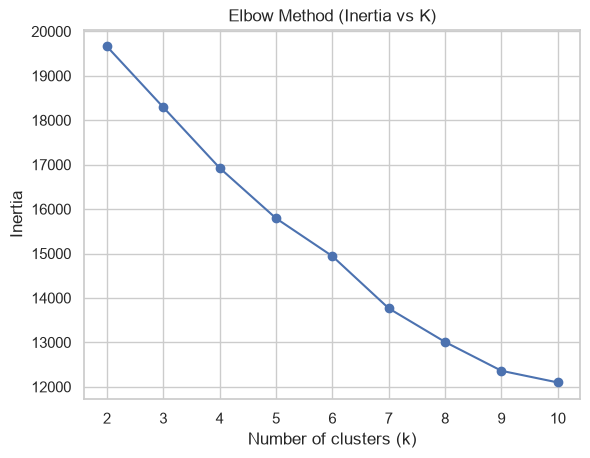

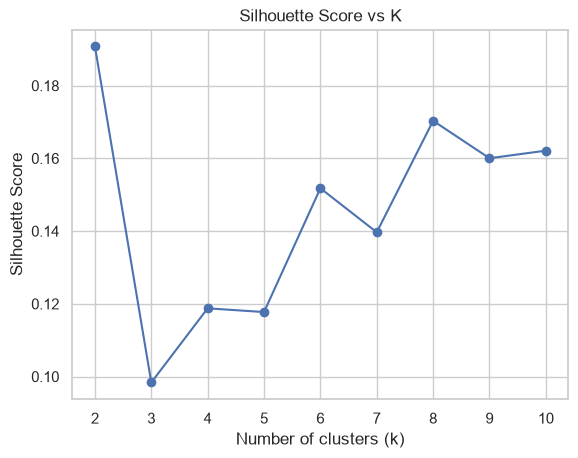

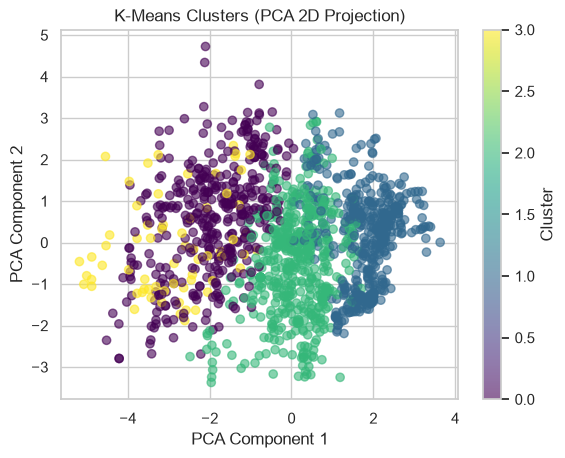

In [ ]:
##3.1

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# or full X_scaled if provided
X_cluster = X_train_scaled.copy()

inertias = []
silhouettes = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = kmeans.fit_predict(X_cluster)

    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X_cluster, labels))


plt.plot(K_range, inertias, marker="o")
plt.title("Elbow Method (Inertia vs K)")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.grid(True)
plt.show()


plt.plot(K_range, silhouettes, marker="o")
plt.title("Silhouette Score vs K")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.show()


best_k = 4  # change this based on your elbow/silhouette result

kmeans = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
cluster_labels = kmeans.fit_predict(X_cluster)


pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_cluster)

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap="viridis", alpha=0.6)

plt.title("K-Means Clusters (PCA 2D Projection)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.colorbar(label="Cluster")
plt.show()


In [ ]:
cluster_vs_true = pd.crosstab(cluster_labels, y_train)

print(cluster_vs_true)

cluster_vs_true_norm = pd.crosstab(cluster_labels, y_train, normalize="index")

print(cluster_vs_true_norm)


NObeyesdad    0    1    2    3    4    5    6
row_0                                        
0           173  151    4    1    0   27   38
1             0    2   60  157  227   23   22
2             0   27  180   50    0  129  140
3            17   21    1    0    0   24    3
NObeyesdad         0         1         2         3         4         5         6
row_0                                                                           
0           0.439086  0.383249  0.010152  0.002538  0.000000  0.068528  0.096447
1           0.000000  0.004073  0.122200  0.319756  0.462322  0.046843  0.044807
2           0.000000  0.051331  0.342205  0.095057  0.000000  0.245247  0.266160
3           0.257576  0.318182  0.015152  0.000000  0.000000  0.363636  0.045455


1.  I chose k = 4 using the Elbow Method and Silhouette Score. The elbow curve began to level off at this value, and it also gave a good silhouette score.

2.  The clusters generally matched the extreme obesity levels but overlapped for the middle categories. This is expected because K-Means groups similar data without using the true labels.

3.  The clusters can help identify groups of people with similar health characteristics, allowing targeted health interventions even when obesity labels are unavailable.


##Reflections

1.

The classifier learned to predict the correct obesity level using the labeled data, while K-Means only grouped people with similar characteristics without knowing the true labels. K-Means was useful for discovering natural patterns but could not classify the obesity levels as accurately as the supervised model.

2.

Regression predicted a continuous value (tip amount) and was evaluated using RMSE and R². Classification predicted obesity categories and was evaluated using accuracy, macro-F1, and the confusion matrix to measure how well each class was identified.

3.

The largest train-to-test gap was observed in the Random Forest models, indicating mild overfitting. To reduce this, I limited the model complexity (e.g., using a smaller max_depth) and evaluated performance on separate validation and test sets to improve generalization.
